In [3]:
## 1.Install Required Libraries!
!pip install pandas numpy scikit-learn matplotlib seaborn joblib


In [4]:
##2.Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import joblib


In [5]:
## Download dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dskagglemt/student-performance-data-set")

print("Path to dataset files:", path)


100%|██████████| 21.6k/21.6k [00:00<00:00, 25.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dskagglemt/student-performance-data-set/versions/1


In [6]:
import pandas as pd
import os

mat_path = os.path.join(path, "student-mat.csv")
por_path = os.path.join(path, "student-por.csv")

mat = pd.read_csv(mat_path, sep=";")
por = pd.read_csv(por_path, sep=";")

df = pd.concat([mat, por], ignore_index=True)
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


STEP 2 — Data Preprocessing & Cleaning

In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_clean = df.copy()

# Identify categorical columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

# Encode categorical columns
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# Check missing values
print("Missing values per column:")
print(df_clean.isnull().sum())

# Drop rows with missing values (this dataset usually has none)
df_clean = df_clean.dropna()

print("Final shape after cleaning:", df_clean.shape)

df_clean.head()


Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
Final shape after cleaning: (1044, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,6,10,10


STEP: Encode Categorical Columns (One-Hot Encoding)

In [9]:
# Encode all categorical columns automatically
df_encoded = pd.get_dummies(df, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
print(df_encoded.head())


Shape after encoding: (1044, 42)
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         3       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  famsup_yes  \
0     1  ...             True           False           True       False   
1     1  ...            False           False          False        True   
2     2  ...             True           False           True       False   
3     1  ...             True           False          False        True   
4     1  ...            False           False          False        True   

   paid_yes  activities_yes  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


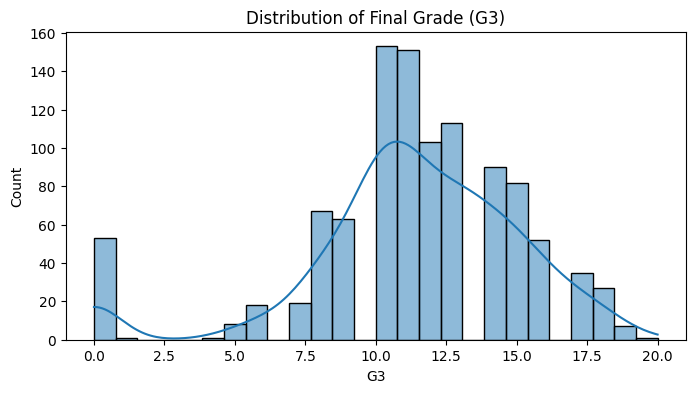

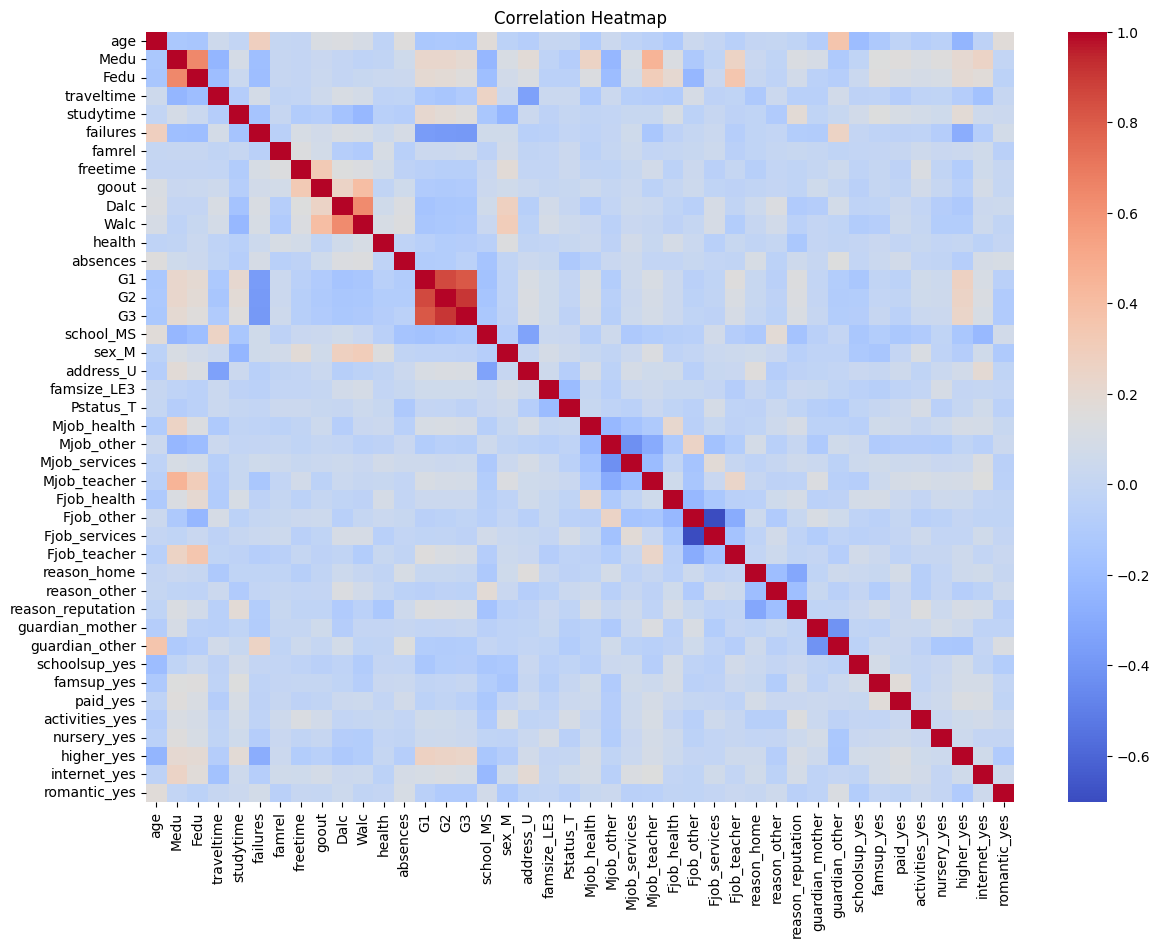


Top correlations with G3:
G3                   1.000000
G2                   0.910743
G1                   0.809142
higher_yes           0.236578
Medu                 0.201472
studytime            0.161629
Fedu                 0.159796
reason_reputation    0.121303
address_U            0.117696
internet_yes         0.107064
Fjob_teacher         0.101361
Mjob_health          0.101349
Mjob_teacher         0.084521
famsize_LE3          0.061209
famrel               0.054461
Mjob_services        0.045015
Fjob_health          0.042101
nursery_yes          0.039950
activities_yes       0.033998
famsup_yes           0.013313
Name: G3, dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Basic info
print("Dataset Info:")
print(df.info())

# Summary statistics
print("\nSummary statistics:")
display(df.describe())

# Distribution of final grade G3
plt.figure(figsize=(8,4))
sns.histplot(df['G3'], kde=True)
plt.title("Distribution of Final Grade (G3)")
plt.show()

# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Top correlations with G3
corr_with_G3 = df_encoded.corr()["G3"].sort_values(ascending=False)
print("\nTop correlations with G3:")
print(corr_with_G3.head(20))



Model Training

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# ---------- 1. FEATURE / TARGET SPLIT ----------
X = df_encoded.drop("G3", axis=1)
y = df_encoded["G3"]

# ---------- 2. TRAIN/TEST SPLIT ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ---------- 3A. LINEAR REGRESSION ----------
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("\n Linear Regression Results:")
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

# ---------- 3B. RANDOM FOREST ----------
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("\n Random Forest Results:")
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

# ---------- OPTIONAL: 3C. XGBOOST (if installed) ----------
try:
    from xgboost import XGBRegressor

    xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5)
    xgb.fit(X_train, y_train)

    xgb_pred = xgb.predict(X_test)

    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
    xgb_r2 = r2_score(y_test, xgb_pred)

    print("\n XGBoost Results:")
    print("RMSE:", xgb_rmse)
    print("R² Score:", xgb_r2)

except Exception as e:
    print("\n XGBoost not installed — skipping")


Train shape: (835, 41)
Test shape: (209, 41)

 Linear Regression Results:
RMSE: 1.7898036875096355
R² Score: 0.7928054519878576

 Random Forest Results:
RMSE: 1.704733446612659
R² Score: 0.8120334845464852

 XGBoost Results:
RMSE: 1.6867158975440144
R² Score: 0.8159857988357544


Plot: Actual vs Predicted (Best Model: XGBoost)

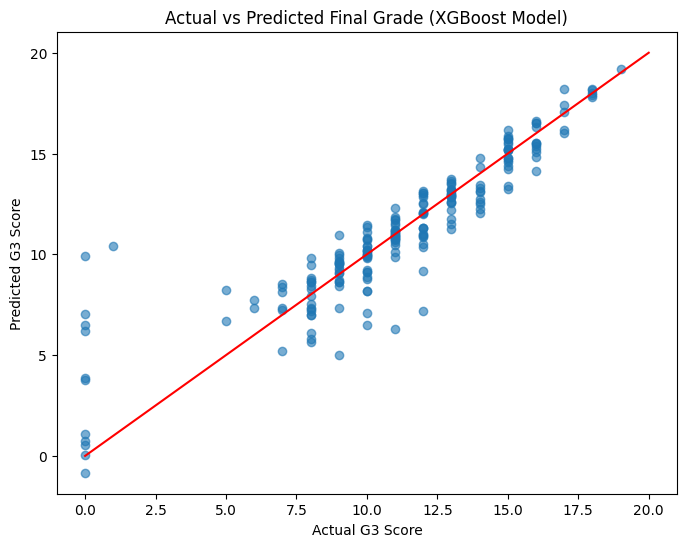

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, xgb_pred, alpha=0.6)
plt.xlabel("Actual G3 Score")
plt.ylabel("Predicted G3 Score")
plt.title("Actual vs Predicted Final Grade (XGBoost Model)")
plt.plot([0,20], [0,20], color='red')  # reference line
plt.show()


Visualization

Feature Importance (Top 15 Features)

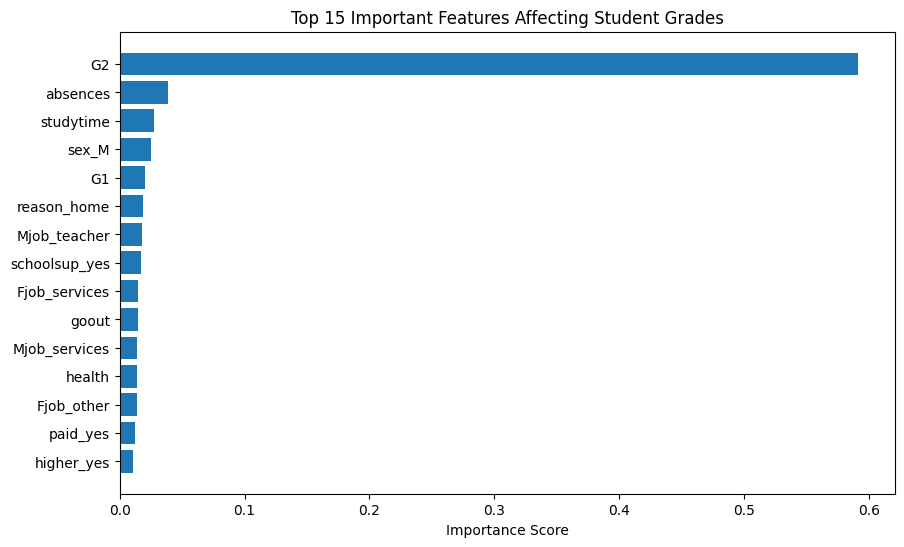

In [14]:
import pandas as pd
import numpy as np

importance = xgb.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features Affecting Student Grades")
plt.xlabel("Importance Score")
plt.show()


1. Actual vs Predicted Graph (Best Model Visualization)

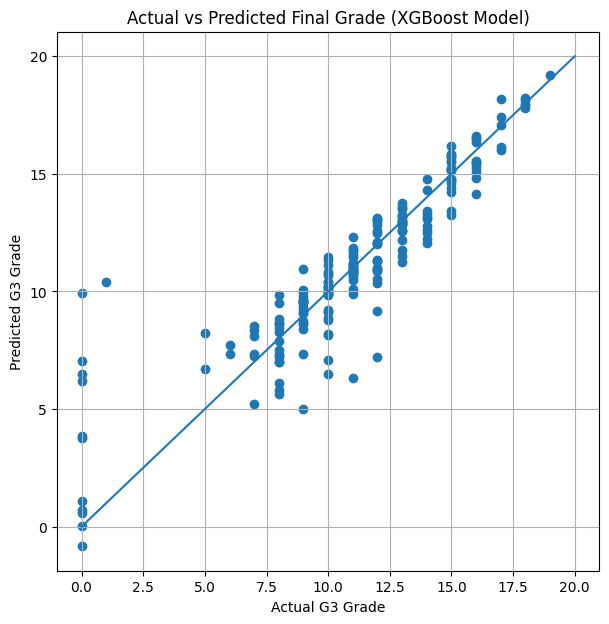

In [15]:
import matplotlib.pyplot as plt

# Best model is XGBoost (you already trained it as xgb)
y_pred = xgb.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred)
plt.plot([0, 20], [0, 20])   # perfect prediction line
plt.xlabel("Actual G3 Grade")
plt.ylabel("Predicted G3 Grade")
plt.title("Actual vs Predicted Final Grade (XGBoost Model)")
plt.grid(True)
plt.show()


2. Residual Plot (Checks prediction errors)

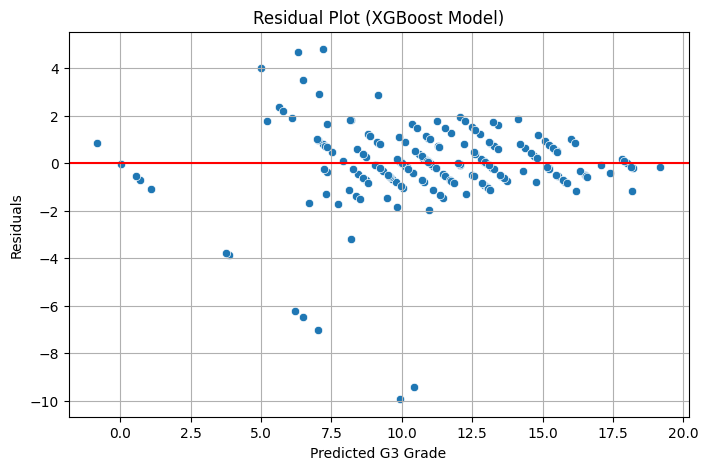

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted G3 Grade")
plt.ylabel("Residuals")
plt.title("Residual Plot (XGBoost Model)")
plt.grid(True)
plt.show()


3. Feature Importance Plot (for XGBoost)

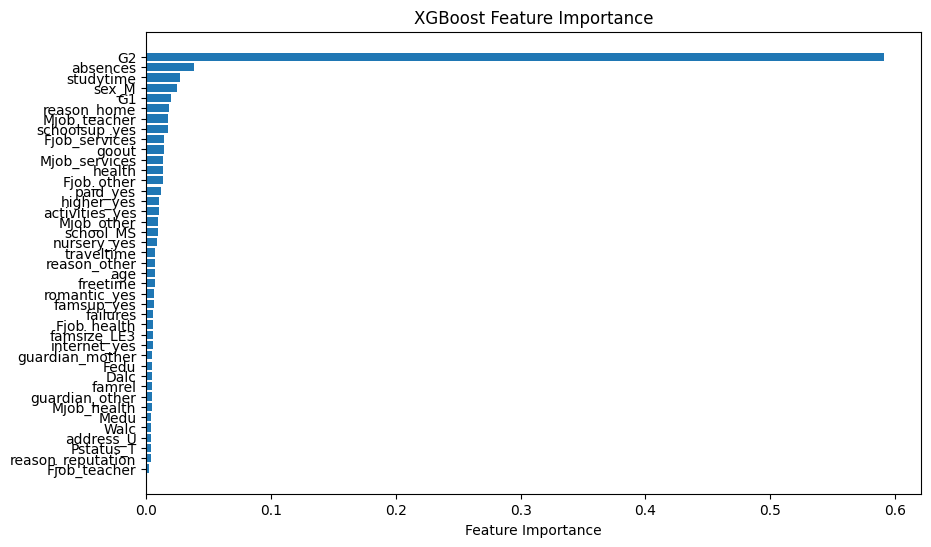

In [17]:
import numpy as np

xgb_importance = xgb.feature_importances_
feature_names = X_train.columns

sorted_idx = np.argsort(xgb_importance)[::-1]

plt.figure(figsize=(10,6))
plt.barh(feature_names[sorted_idx], xgb_importance[sorted_idx])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()


4. Distribution of G3 (Target Variable)

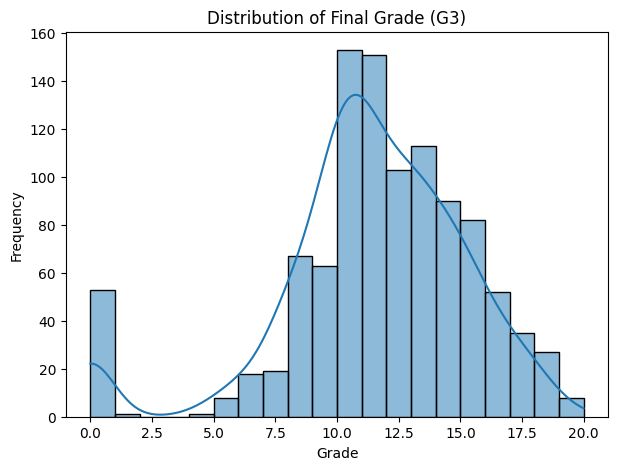

In [18]:
plt.figure(figsize=(7,5))
sns.histplot(df['G3'], bins=20, kde=True)
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Grade")
plt.ylabel("Frequency")
plt.show()


Distribution of Final Grades (G3 Histogram)

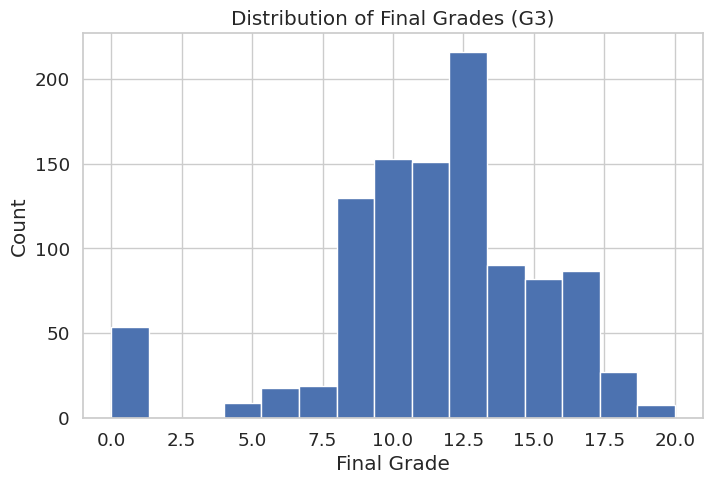

In [42]:
plt.figure(figsize=(8,5))
plt.hist(df['G3'], bins=15)
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Count")
plt.show()


Study Time vs Final Grade (Box Plot)

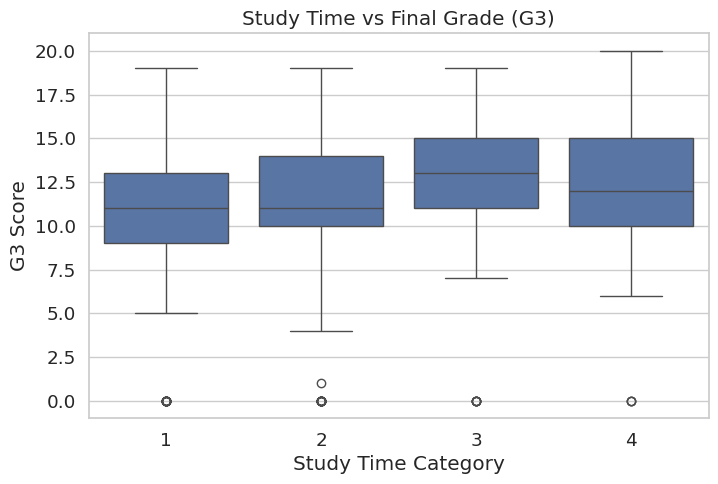

In [43]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['studytime'], y=df['G3'])
plt.title("Study Time vs Final Grade (G3)")
plt.xlabel("Study Time Category")
plt.ylabel("G3 Score")
plt.show()


Compare All Model Errors (Bar Graph: Choose Best Model)

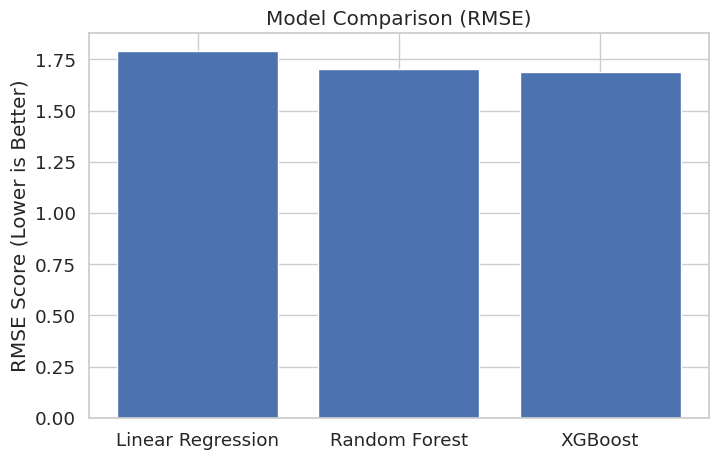

In [41]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']
rmse_scores = [1.7898, 1.7047, 1.6867]

plt.figure(figsize=(8,5))
plt.bar(models, rmse_scores)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE Score (Lower is Better)")
plt.show()


Prediction Error Distribution (Residual Plot)

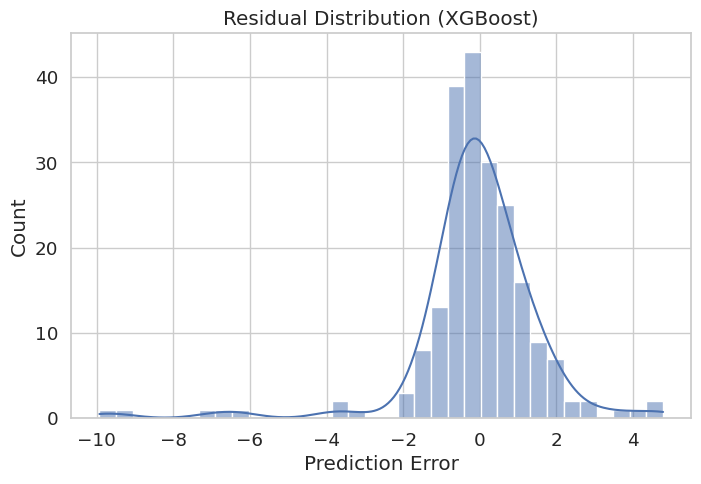

In [44]:
residuals = y_test - xgb_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (XGBoost)")
plt.xlabel("Prediction Error")
plt.show()


/tmp/ipython-input-275261352.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='G3', palette="Set2")


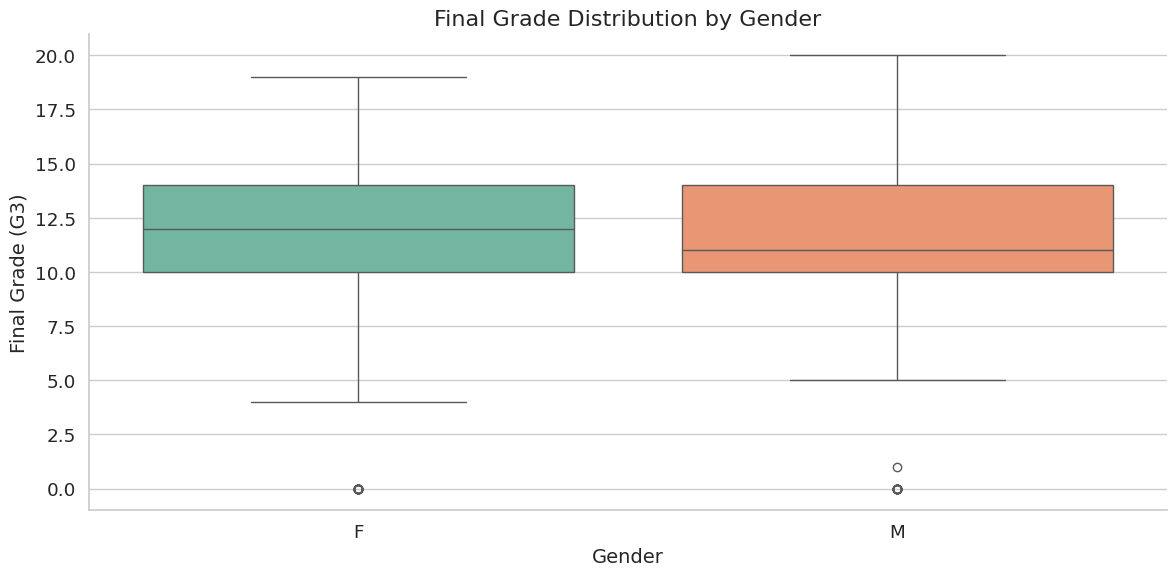

In [45]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='sex', y='G3', palette="Set2")
plt.title("Final Grade Distribution by Gender", fontsize=16)
plt.xlabel("Gender", fontsize=14)
plt.ylabel("Final Grade (G3)", fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()


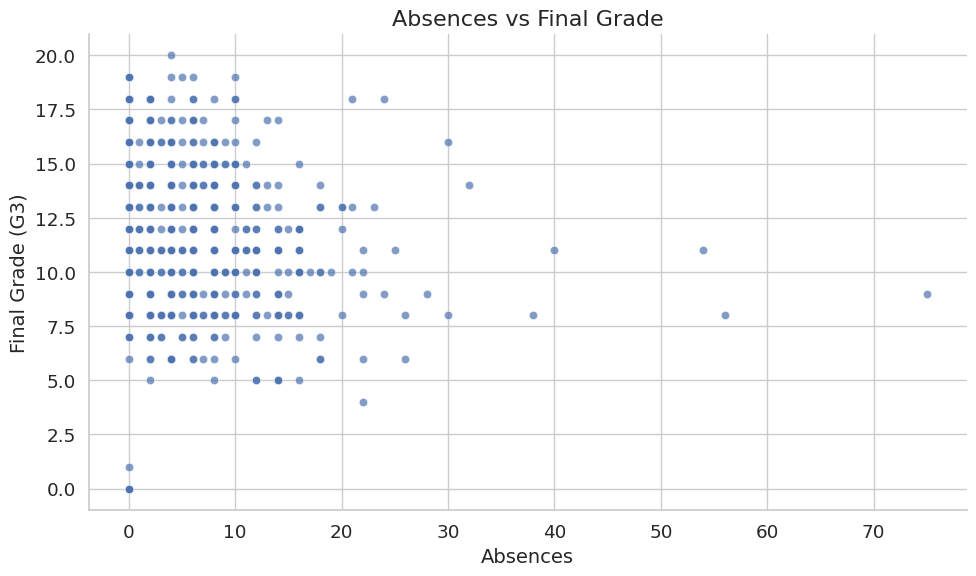

In [46]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='absences', y='G3', alpha=0.7, color="#4C72B0")
plt.title("Absences vs Final Grade", fontsize=16)
plt.xlabel("Absences", fontsize=14)
plt.ylabel("Final Grade (G3)", fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()


In [38]:
df['Performance'] = pd.cut(
    df['G3'],
    bins=[-1, 10, 15, 20],
    labels=['Low', 'Medium', 'High']
)


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector,

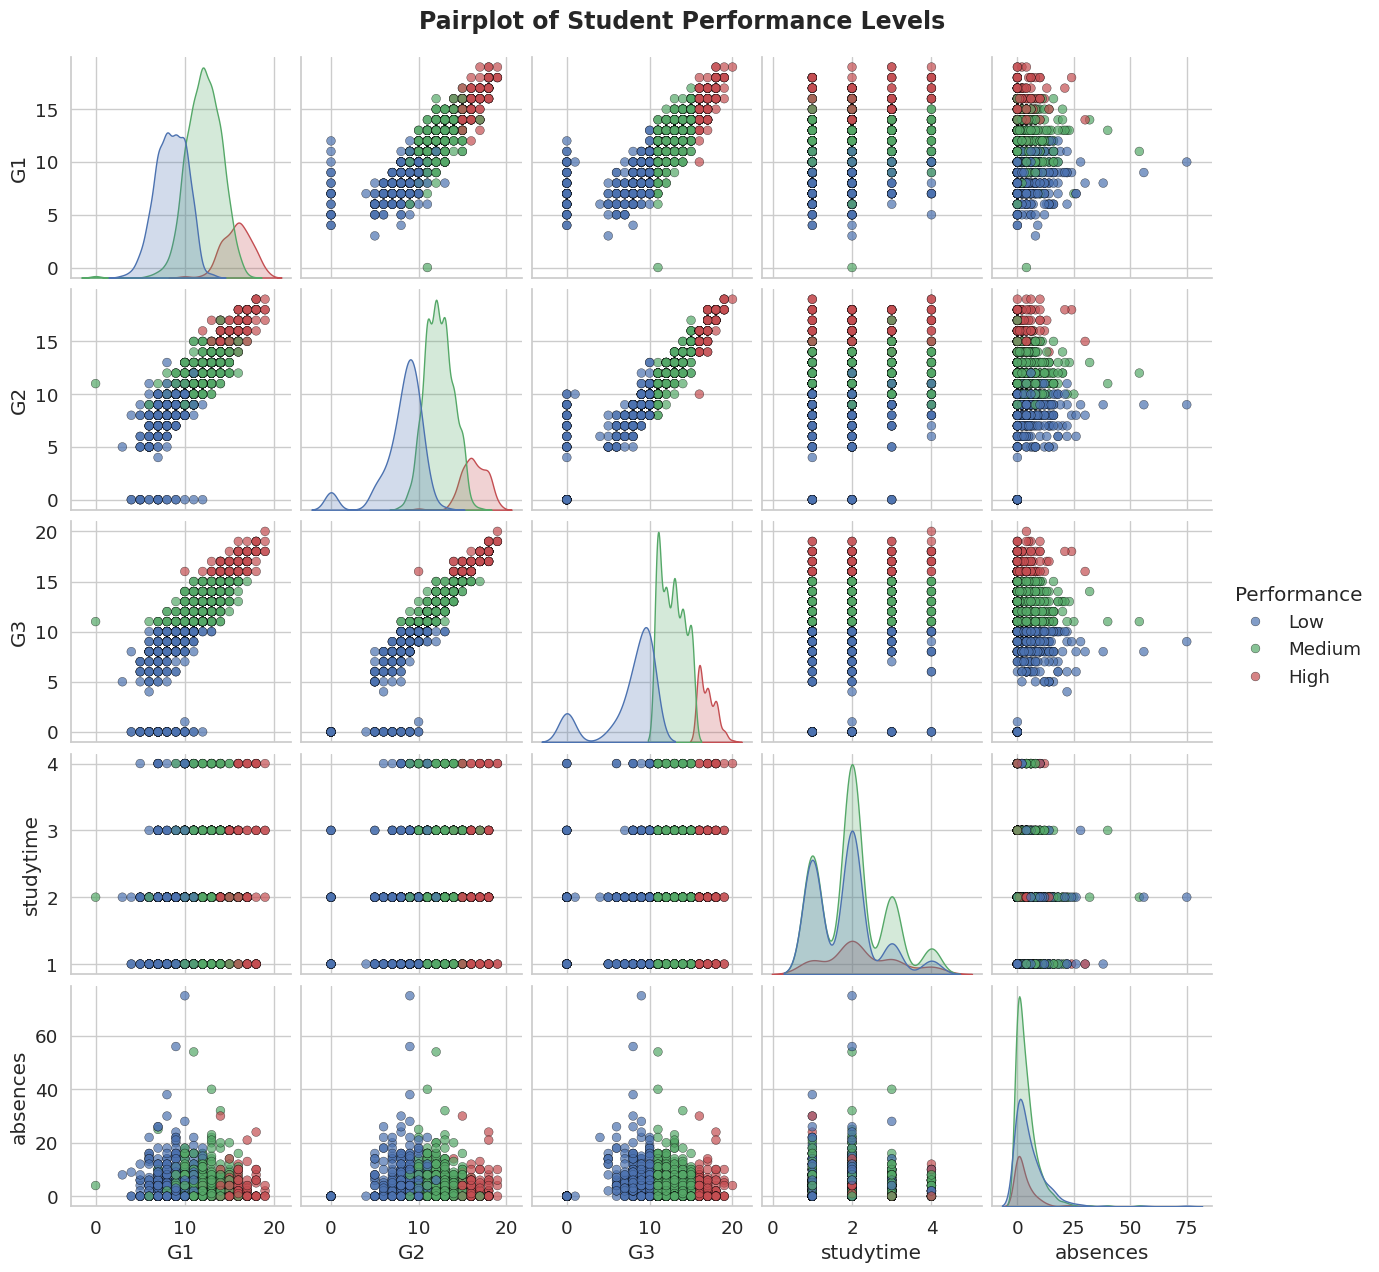

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.2)

# beautiful 3-color palette (green-blue like Iris)
palette = sns.color_palette(["#4C72B0", "#55A868", "#C44E52"])

numeric_cols = ['G1', 'G2', 'G3', 'studytime', 'absences']

sns.pairplot(
    df[numeric_cols + ['Performance']],
    hue="Performance",
    diag_kind="kde",
    palette=palette,
    plot_kws={'alpha': 0.7, 's': 40, 'edgecolor': 'black', 'linewidth': 0.3},
    diag_kws={'shade': True}
)

plt.suptitle("Pairplot of Student Performance Levels", y=1.02, fontsize=17, fontweight='bold')
plt.show()
